# AQI Prediction — Indian Cities
Predicting Air Quality Index (AQI) from pollutant concentrations across Indian cities.

**Models Used:** Linear Regression, Random Forest Regressor
**Dataset:** City-level daily AQI data — includes PM2.5, PM10, NO2, CO, SO2, O3 and more

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## Loading the Dataset
Single CSV containing city-wise daily pollutant readings and AQI values.

In [2]:
df = pd.read_csv("../Datasets/AQI dataset/city_day.csv")
print(df.shape)
df.head()

(29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


## Null Value Analysis
AQI dataset has significant missing data — pollutants are not always measured every day in every city.

In [4]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

## AQI Distribution
Understanding how AQI values are spread across all cities and dates.

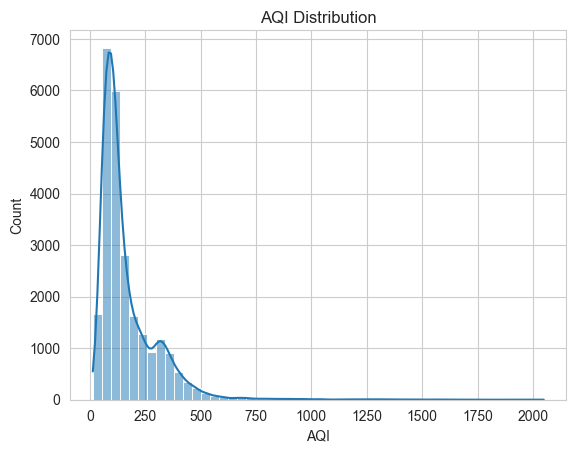

In [5]:
sns.histplot(df["AQI"].dropna(), bins=50, kde=True)
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.show()

> AQI is right-skewed — most readings fall in the moderate range,
> but a long tail of high-pollution days pulls the distribution right.

## Most Polluted Cities
Ranking cities by average AQI to identify the worst affected regions.

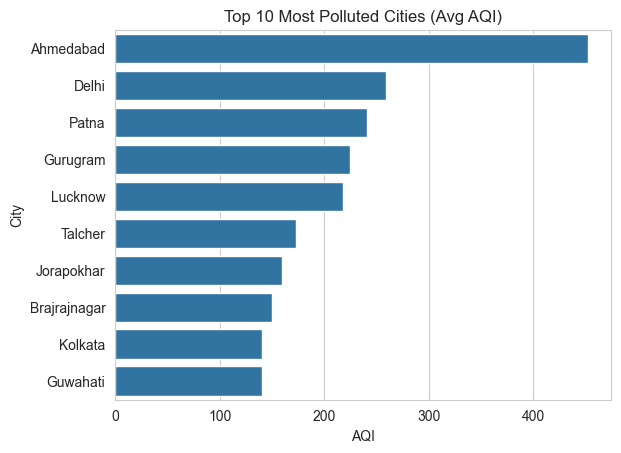

In [6]:
data = df.groupby("City")["AQI"].mean().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x="AQI", y="City", data=data)
plt.title("Top 10 Most Polluted Cities (Avg AQI)")
plt.show()

> Cities in North India (Delhi, Patna, Ahmedabad) consistently top the pollution charts —
> driven by industrial activity, vehicular density, and seasonal crop burning.

## AQI Trend Over Time
Plotting average daily AQI across all cities to spot seasonal and yearly patterns.

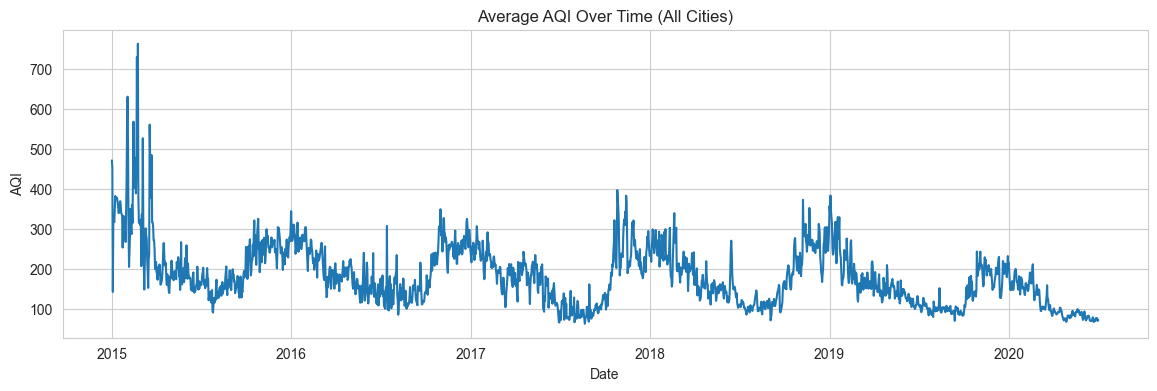

In [7]:
df["Date"] = pd.to_datetime(df["Date"])
daily_aqi = df.groupby("Date")["AQI"].mean()
plt.figure(figsize=(14, 4))
plt.plot(daily_aqi)
plt.title("Average AQI Over Time (All Cities)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.show()

> AQI spikes noticeably in winter months (Oct–Jan) — consistent with temperature inversions
> trapping pollutants close to ground level, and increased crop stubble burning in North India.

## Pollutant Correlation with AQI
Identifying which pollutants have the strongest relationship with AQI.
This guides feature selection and helps understand what drives air quality deterioration.

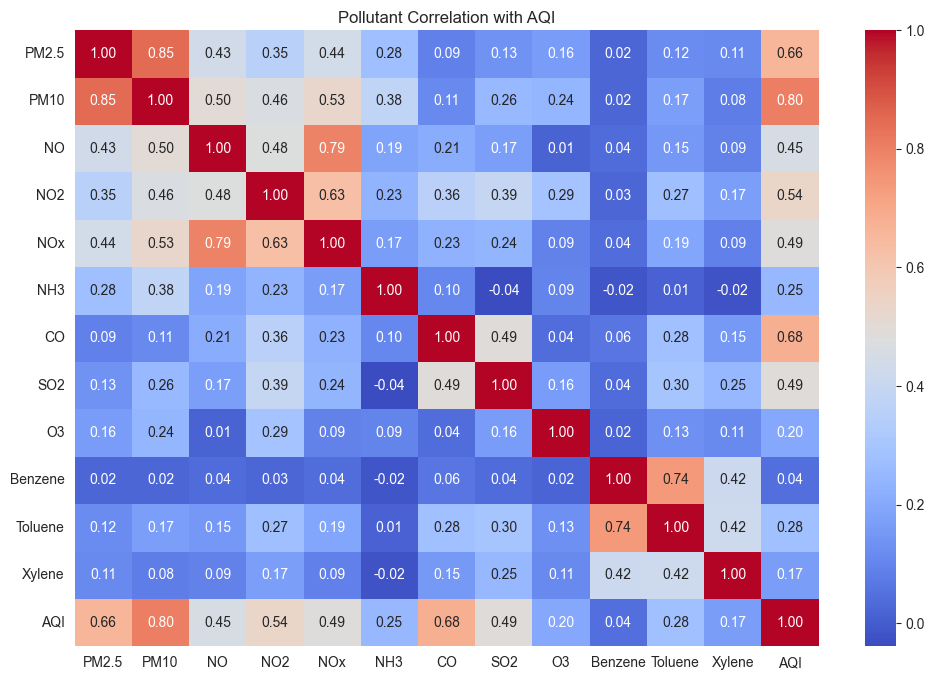

In [8]:
pollutants = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene", "AQI"]
plt.figure(figsize=(12, 8))
sns.heatmap(df[pollutants].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pollutant Correlation with AQI")
plt.show()

> PM2.5 and PM10 show the strongest correlation with AQI — fine particulate matter
> is the primary driver of poor air quality in Indian cities.
> NO, NO2, NOx are moderately correlated. CO, Benzene, and Xylene show weaker direct correlation.

## Preprocessing
### Step 1 — Drop rows with missing AQI
AQI is our target variable — rows without it cannot be used for training or evaluation.

In [9]:
df = df.dropna(subset=["AQI"])
print("Shape after dropping null AQI:", df.shape)

Shape after dropping null AQI: (24850, 16)


### Step 2 — Fill Missing Pollutant Values
Filling missing pollutant readings with **column-wise median** — median is robust to the
extreme pollution spikes that skew the mean in this dataset.

In [10]:
pollutant_cols = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene"]
for col in pollutant_cols:
    df[col] = df[col].fillna(df[col].median())

## Feature Engineering
Extracting `Month` and `Year` from the Date column to capture seasonal and yearly pollution trends.

In [11]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

## Preparing Model Features
Dropping columns not suitable for modeling:
- `AQI_Bucket` — a categorical label derived directly from AQI, would cause data leakage
- `City` and `Date` — identifiers, not predictive features for a regression model

In [12]:
# AQI_Bucket is derived from AQI, City and Date not needed for LR
df_model = df.drop(columns=["City", "Date", "AQI_Bucket"])
df_model.head()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Month,Year
28,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,0.00,3.14,209.0,1,2015
29,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,0.00,4.81,328.0,1,2015
30,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,0.01,7.67,514.0,1,2015
31,135.99,96.18,43.48,42.08,84.57,16.31,43.48,75.23,102.70,0.40,0.04,25.87,782.0,2,2015
32,178.33,96.18,54.56,35.31,72.80,16.31,54.56,55.04,107.38,0.46,0.06,35.61,914.0,2,2015


In [13]:
X = df_model.drop(columns=["AQI"])
y = df_model["AQI"]
print("Features:", X.columns.tolist())

Features: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Month', 'Year']


## Train/Test Split
Using a **random split** here — unlike the Rossmann project, this dataset aggregates readings
across many cities independently, so there's no single time series that would leak future data.
A random 80/20 split is appropriate.

In [14]:
# Using random split here since this is city-level aggregated data, not a single time series
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (19880, 14) | Test size: (4970, 14)


## Model 1 — Linear Regression
Starting with Linear Regression as a baseline to understand how much of AQI variance
can be explained by a simple linear combination of pollutants.

In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression → RMSE: {rmse_lr:.2f} | R²: {r2_lr:.4f}")

Linear Regression → RMSE: 59.27 | R²: 0.8082


> Note the R² score — if it's high here (unlike Rossmann), it's because AQI is mathematically
> computed from pollutant concentrations, so a near-linear relationship exists by definition.

## Linear Regression — Actual vs Predicted

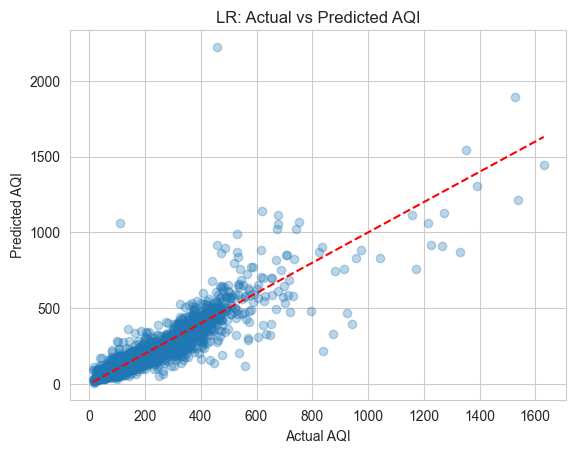

In [16]:
plt.scatter(y_test, y_pred_lr, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("LR: Actual vs Predicted AQI")
plt.show()

> Points clustering tightly around the red line indicate the model is capturing
> the AQI-pollutant relationship well at lower AQI values.
> Scatter increases at higher AQI — extreme pollution events are harder to predict linearly.

## Linear Regression — Residual Plot
A good model's residuals scatter randomly around zero. Any visible pattern means
the model is missing structure in the data.

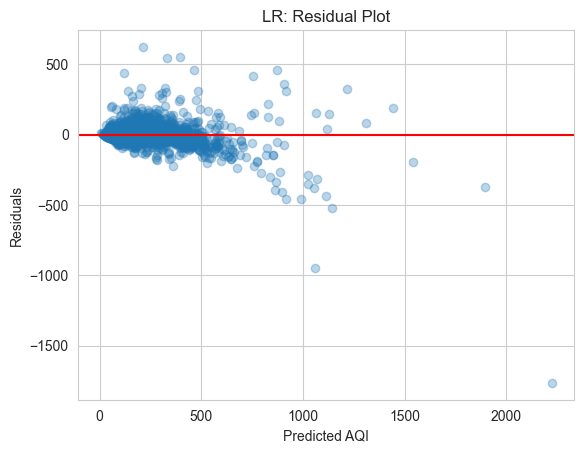

In [17]:
residuals = y_test - y_pred_lr
plt.scatter(y_pred_lr, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Predicted AQI")
plt.ylabel("Residuals")
plt.title("LR: Residual Plot")
plt.show()

> Residuals show a slight fan shape at higher predictions — variance increases with AQI,
> suggesting the linear model underestimates during severe pollution episodes.

## Model 2 — Random Forest Regressor
Random Forest builds multiple decision trees and averages their predictions.
It handles non-linear relationships and feature interactions that Linear Regression cannot capture.
Using 100 trees as a starting point.

In [18]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest → RMSE: {rmse_rf:.2f} | R²: {r2_rf:.4f}")

Random Forest → RMSE: 40.72 | R²: 0.9094


> Compare RF metrics against LR — a significant R² improvement confirms non-linear
> pollutant interactions that LR was missing.

## Random Forest — Actual vs Predicted

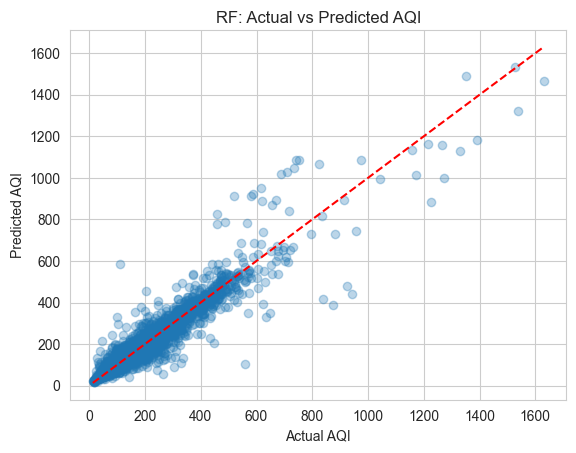

In [19]:
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("RF: Actual vs Predicted AQI")
plt.show()

## Feature Importance — Random Forest
Identifying which pollutants the Random Forest relied on most heavily for predictions.

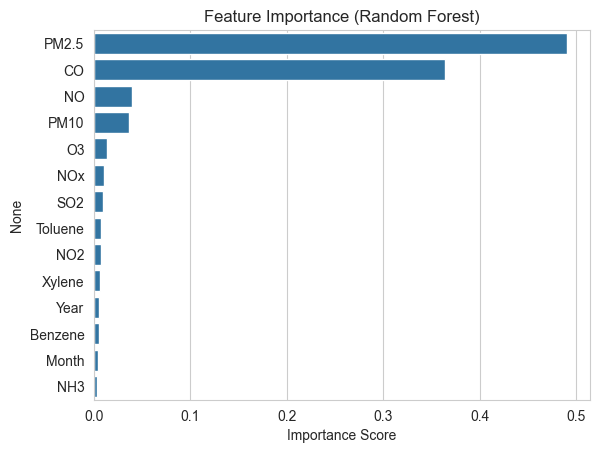

In [20]:
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

> PM2.5 dominates feature importance — consistent with the correlation heatmap.
> This aligns with real-world understanding: fine particulate matter is the
> primary component in India's AQI calculation.

In [21]:
print(importance)

PM2.5      0.490300
CO         0.364381
NO         0.039371
PM10       0.036259
O3         0.013564
NOx        0.010671
SO2        0.009161
Toluene    0.006912
NO2        0.006901
Xylene     0.005834
Year       0.005193
Benzene    0.005000
Month      0.003536
NH3        0.002917
dtype: float64


## Model Comparison Summary

In [22]:
print(f"{'Model':<20} {'RMSE':>8} {'R²':>8}")
print(f"{'Linear Regression':<20} {rmse_lr:>8.2f} {r2_lr:>8.4f}")
print(f"{'Random Forest':<20} {rmse_rf:>8.2f} {r2_rf:>8.4f}")

Model                    RMSE       R²
Linear Regression       59.27   0.8082
Random Forest           40.72   0.9094


## Conclusion
- **Linear Regression** performs surprisingly well here because AQI is formulaically derived from pollutants — a near-linear relationship exists by design
- **Random Forest** improves further by capturing non-linear interactions between pollutants
- **PM2.5 and PM10** are the dominant predictors — consistent with India's AQI methodology
- Winter seasonality (Month feature) adds meaningful signal for high-pollution episodes
- **Next step:** Time-series forecasting per city using ARIMA or Prophet for true temporal predictions